In [ ]:
benchmark_df

,Unnamed: 0,pseudotime_correlation,velocity_cbdir,velocity_icvcoh,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones,...,lm_rsq,featureimp_cor,featureimp_wcor,id,type,time,time_text,memory,memory_text,overall
0,20251027_113203__palantir-cfe_docker__KZ09bCCcFo,0.991,0.687,1.000,0.0,0.000,0.267,0.618,0.189,0.278,...,0.158,0.667,0.621,palantir,Velocity,36.345,36s,4848.93,5G,0.431
1,20251027_113240__stavia-cfe_docker__j0LT2KQ9PJ,0.561,0.375,0.767,0.0,0.000,0.000,0.000,0.305,0.360,...,0.824,0.905,0.852,stavia,Linear,32.645,33s,1030.08,1G,0.000
2,20251027_113107__scvelo-cfe_docker__ixvmqI5sTG,0.505,0.767,0.880,0.0,0.889,0.799,0.870,1.000,1.000,...,1.000,1.000,1.000,scvelo,Velocity,50.893,51s,4734.86,5G,0.746


No legends were provided, trying to automatically infer legends.
Some palettes were not used in the column info, adding legends for them:palette3, white6black4, palette2, palette1
Legend {'title': 'palette3', 'palette': 'palette3', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'palette3', 'palette': 'palette3', 'enabled': True, 'geom': 'bar'} did not contain labels, inferring from the geom.
Legend {'title': 'palette3', 'palette': 'palette3', 'enabled': True, 'geom': 'bar', 'labels': ['0', '', '0.2', '', '0.4', '', '0.6', '', '0.8', '', '1'], 'size': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]} did not contain color, inferring from the palette.
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True} did not contain a geom, inferring from the column_info.
Legend {'title': 'white6black4', 'palette': 'white6black4', 'enabled': True, 'geom': 'text'} did not contain labels, inferring from the geom.
Legend {'title': 'white6black4', 'palet

<Figure size 3200x2400 with 0 Axes>

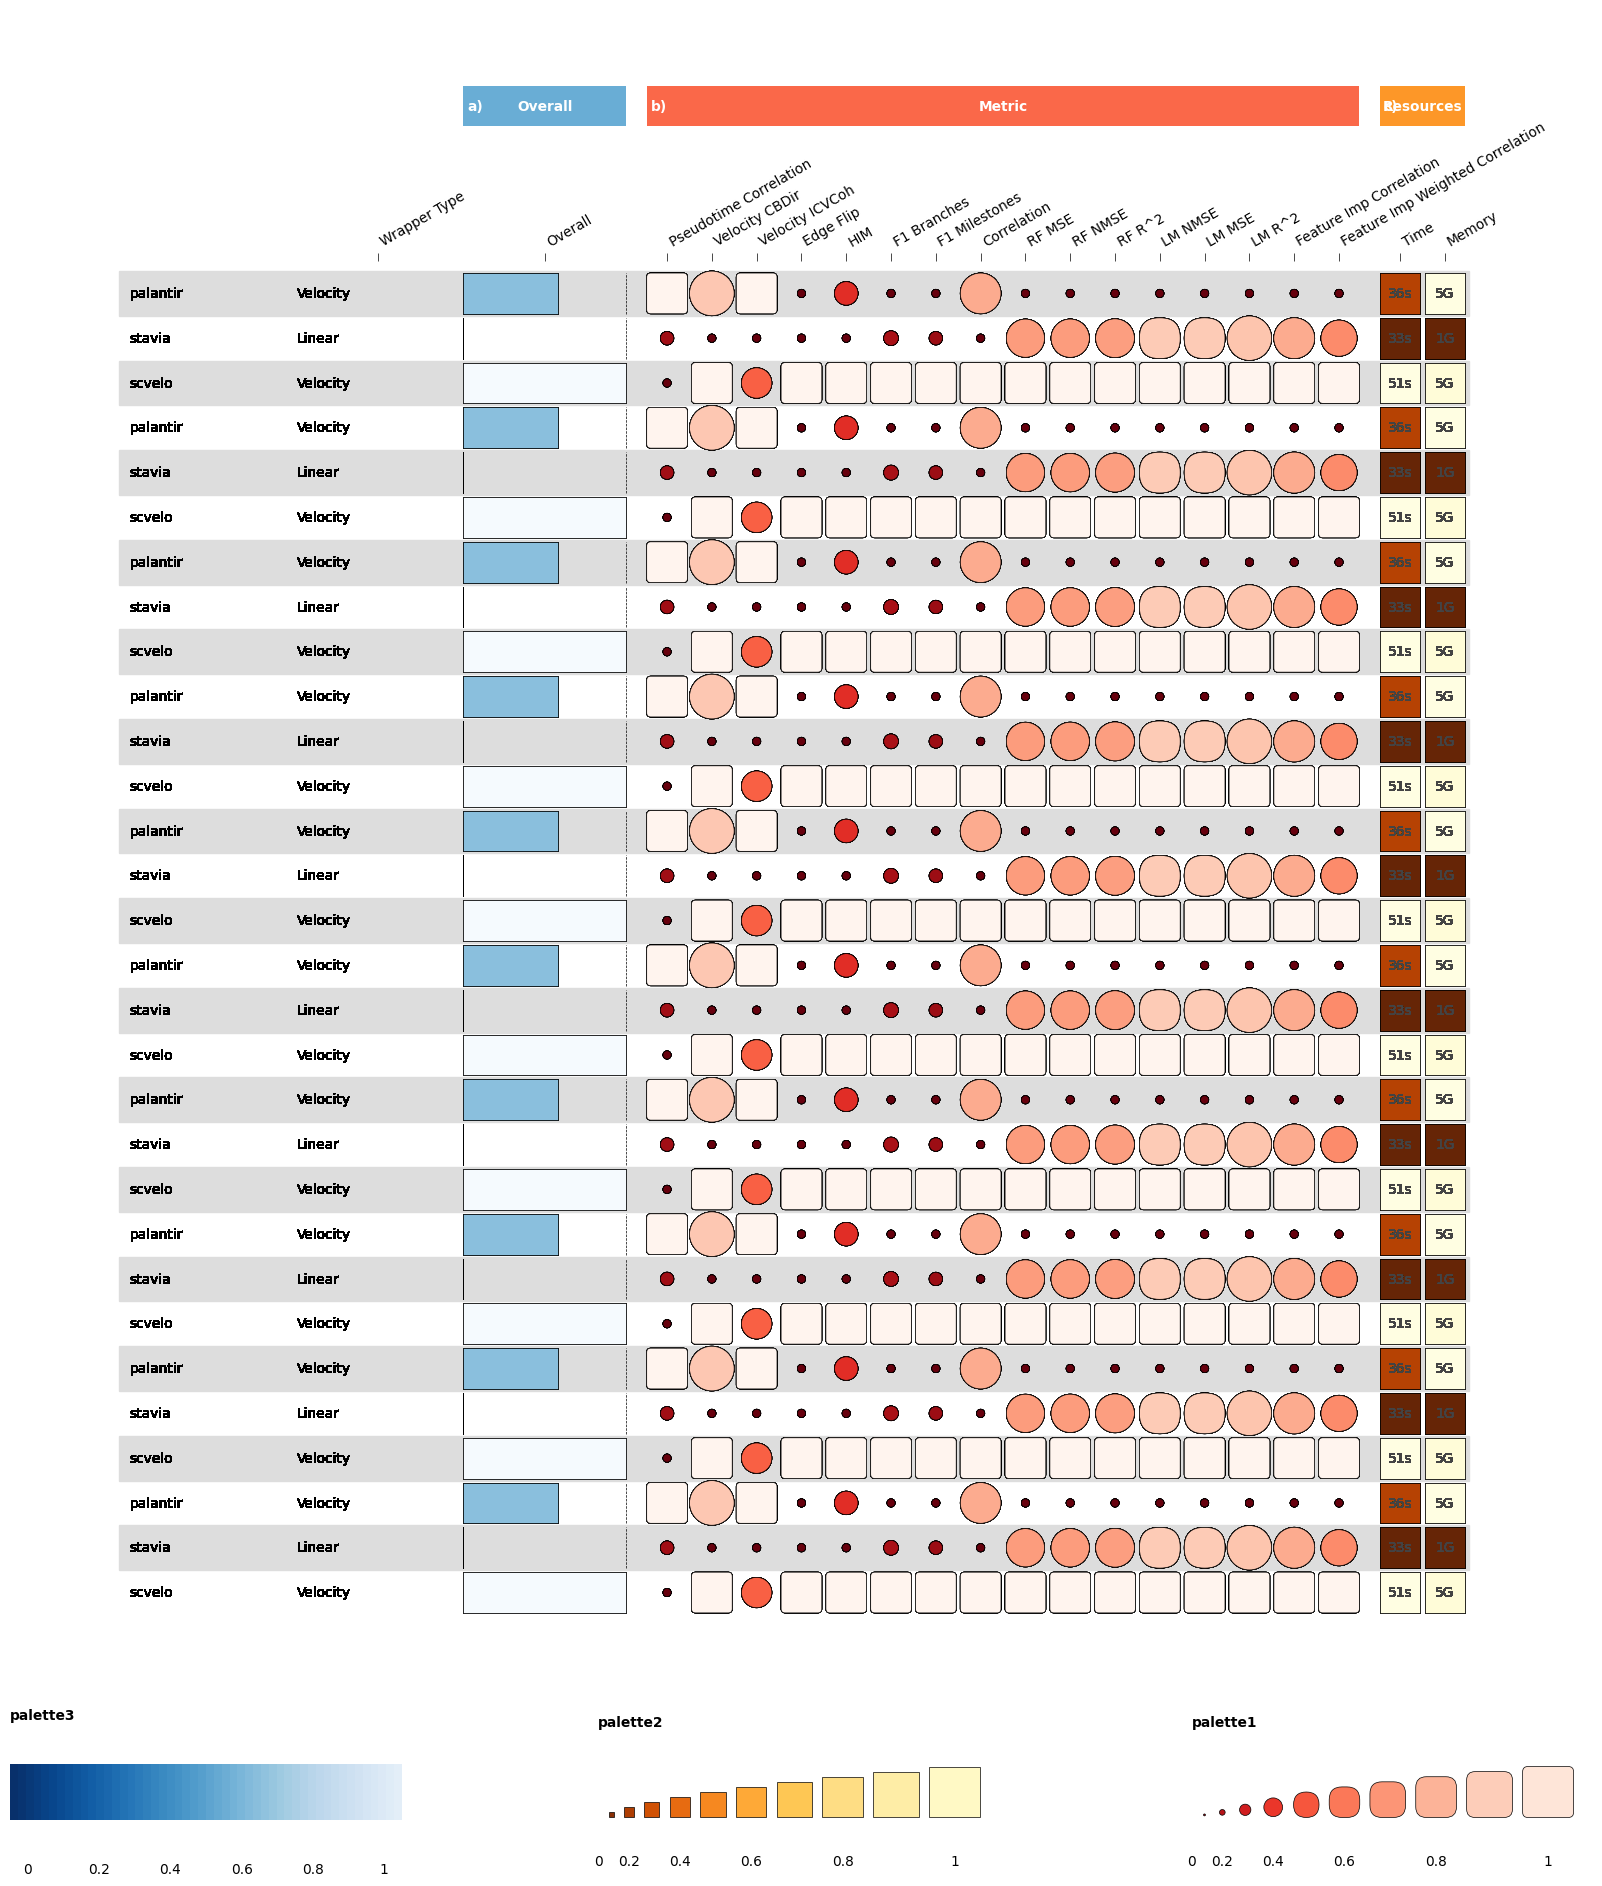

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import funkyheatmappy

plt.figure(figsize=(32, 24))

# 样式参考dynbenchmark: https://funkyheatmap.github.io/funkyheatmap/articles/dynbenchmark.html
benchmark_df = pd.read_csv("pancreas_benchmark_df.csv")
benchmark_df = pd.concat([benchmark_df] * 10, ignore_index=True)

column_list = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 4}, np.nan],
    ["type", np.nan, "Wrapper Type", "text", {"ha": 0, "width": 4}, np.nan],
    ["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "palette3"],
    # metric group, added by latter 'id2name' dict
    # resource group
    ["time", "group2", "Time", "rect", "scaling", "palette2"],
    ["time_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"],  # add time value text
    ["memory", "group2", "Memory", "rect", "scaling", "palette2"],
    ["memory_text", "group2", "", "text", {"overlay": True, "size": 3, "scale": False}, "white6black4"],  # add memory value text

]

id2name = {
    "pseudotime_correlation": "Pseudotime Correlation",
    "velocity_cbdir": "Velocity CBDir",
    "velocity_icvcoh": "Velocity ICVCoh",
    "edge_flip": "Edge Flip",
    "him": "HIM",
    # "isomorphic": "Isomorphic",
    "F1_branches": "F1 Branches",
    "F1_milestones": "F1 Milestones",
    "correlation": "Correlation",
    "rf_mse": "RF MSE",
    "rf_nmse": "RF NMSE",
    "rf_rsq": "RF R^2",
    "lm_nmse": "LM NMSE",
    "lm_mse": "LM MSE",
    "lm_rsq": "LM R^2",
    "featureimp_cor": "Feature Imp Correlation",
    "featureimp_wcor": "Feature Imp Weighted Correlation",
}

metric_column_list = []
for id, name in id2name.items():
    metric_column_list.append([id, "group1", name, "funkyrect", "options", "palette1"])
column_list = column_list[:4] + metric_column_list + column_list[4:]

column_info = pd.DataFrame(column_list[1:], columns=column_list[0])
column_info.index = column_info["id"]

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[["Overall", "overall", "palette3"],
          ["Metric", "group1", "palette1"],
          ["Resources", "group2", "palette2"]]
)

funkyheatmappy.funky_heatmap(benchmark_df, column_info=column_info, column_groups=column_groups)

plt.savefig("benchmark_heatmap.pdf", dpi=300)
plt.show()